## Import Libraries

In [1]:
# Import Required Libraries

import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

## Load the Dataset

In [2]:
# Load dataset
df = pd.read_csv("bank-full.csv", sep=";")

## Basic Information

In [3]:
# Display first five rows
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [4]:
# Dataset shape
print("Dataset Shape:", df.shape)

Dataset Shape: (45211, 17)


In [5]:
# column names
print(df.columns)

Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'y'],
      dtype='object')


In [6]:
# Dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


In [7]:
# missing values
df.isnull().sum()

,0
age,0
job,0
marital,0
education,0
default,0
balance,0
housing,0
loan,0
contact,0
day,0


In [8]:
# Statistical Summary
df.describe()

,age,balance,day,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


## Duplicated Rows


In [9]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


## Preview Target Variable

In [11]:
df['y'].value_counts()

,count
y,
no,39922
yes,5289


## Dataset Overview

In [12]:
print(df.sample(5))

       age         job   marital  education default  balance housing loan  \
9614    57  technician  divorced  secondary      no      204      no   no   
45154   63     retired   married    primary      no     3738      no   no   
6127    33  technician  divorced  secondary      no     -119     yes   no   
42691   28  management   married   tertiary      no      893      no   no   
17402   41      admin.   married   tertiary      no       96     yes   no   

         contact  day month  duration  campaign  pdays  previous poutcome   y  
9614     unknown    6   jun        97         5     -1         0  unknown  no  
45154  telephone    9   nov       301         1    456         4  failure  no  
6127     unknown   27   may       150         1     -1         0  unknown  no  
42691   cellular   18   jan       204         2     94         2  success  no  
17402   cellular   28   jul       269         7     -1         0  unknown  no  


## Exploratory Data Analysis (EDA)

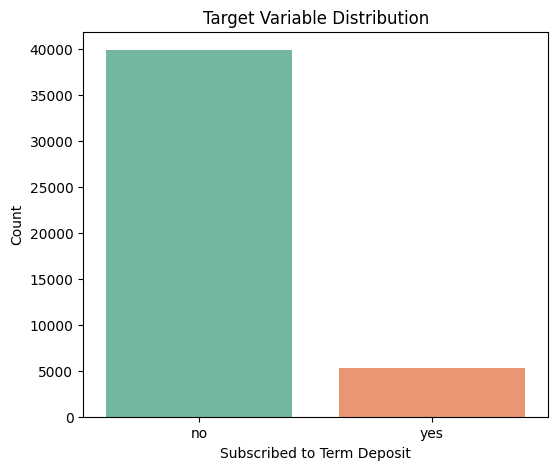

In [13]:
# Target Variable Distribution

plt.figure(figsize=(6,5))
sns.countplot(x='y', data=df, palette='Set2')

plt.title("Target Variable Distribution")
plt.xlabel("Subscribed to Term Deposit")
plt.ylabel("Count")

plt.show()

### Observation

The dataset is imbalanced. Most customers did not subscribe ("no"), while a smaller proportion subscribed ("yes").

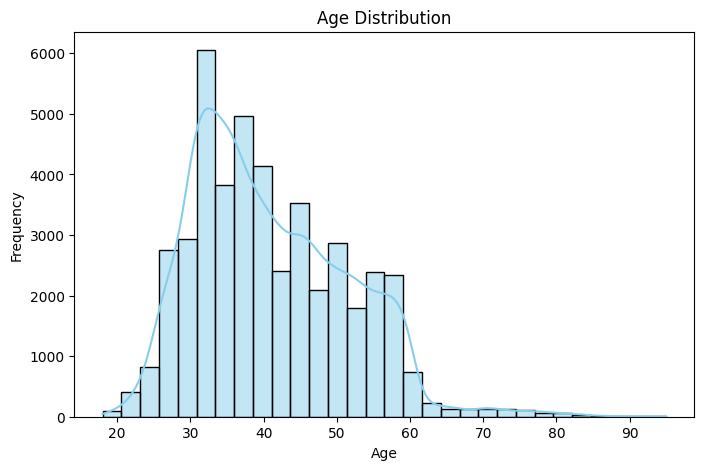

In [14]:
# Age Distribution
plt.figure(figsize=(8,5))

sns.histplot(df['age'], bins=30, kde=True, color='skyblue')

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.show()

### Observation

Most customers are between 30 and 50 years old.

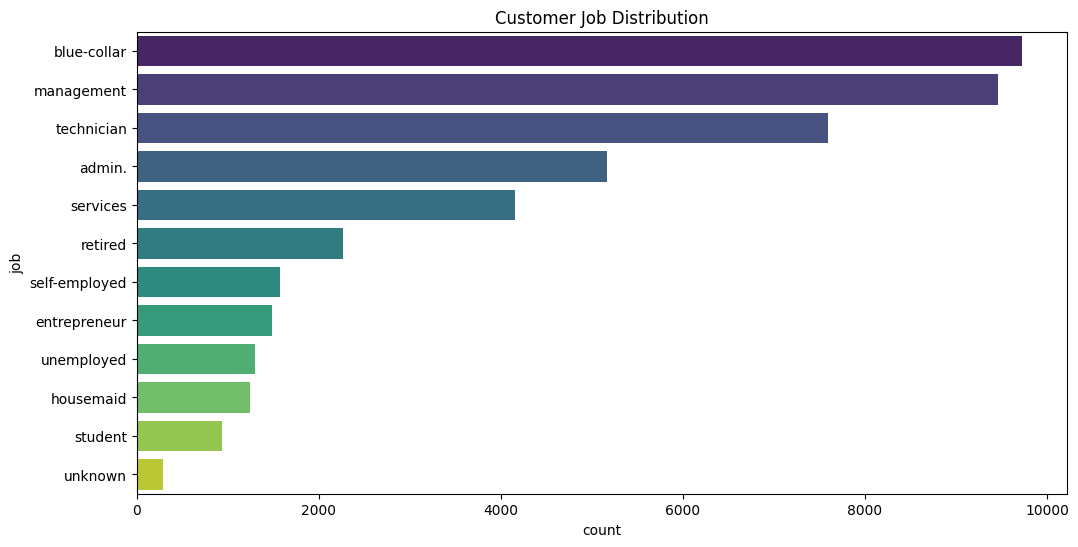

In [15]:
# Job Distribution
plt.figure(figsize=(12,6))

sns.countplot(
    y='job',
    data=df,
    order=df['job'].value_counts().index,
    palette='viridis'
)

plt.title("Customer Job Distribution")

plt.show()

### Observation

The majority of customers work in blue-collar, management, and technician jobs.

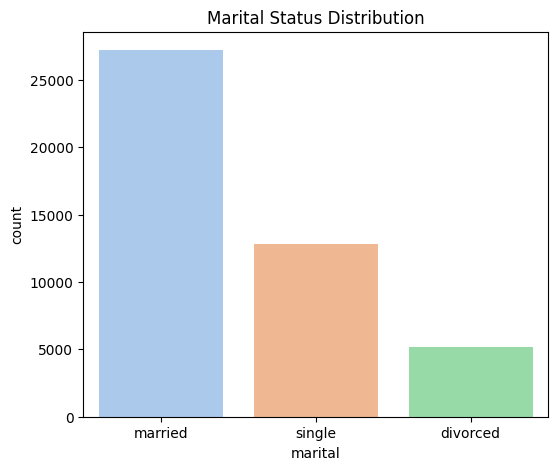

In [16]:
# Martial Status Distribution
plt.figure(figsize=(6,5))

sns.countplot(x='marital', data=df, palette='pastel')

plt.title("Marital Status Distribution")

plt.show()

### Observation

Most customers are married, followed by single customers.

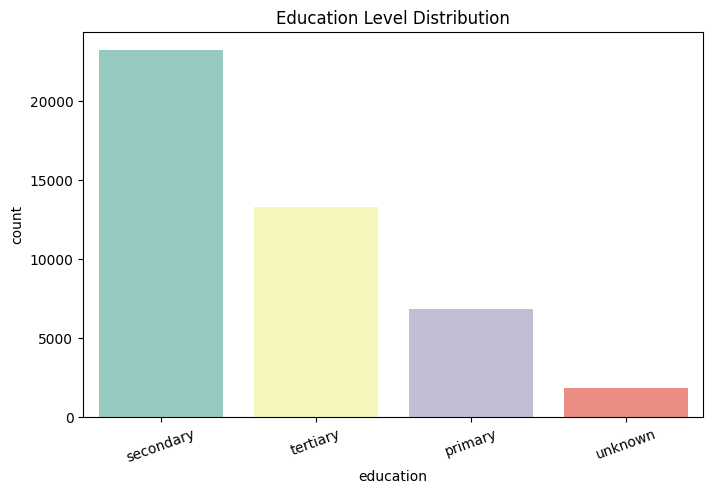

In [17]:
# Education Level Distribution
plt.figure(figsize=(8,5))

sns.countplot(
    x='education',
    data=df,
    order=df['education'].value_counts().index,
    palette='Set3'
)

plt.title("Education Level Distribution")

plt.xticks(rotation=20)

plt.show()

### Observation
  The  highest Education level is of customers is Secondary followed by tertiary, primary, and unknown

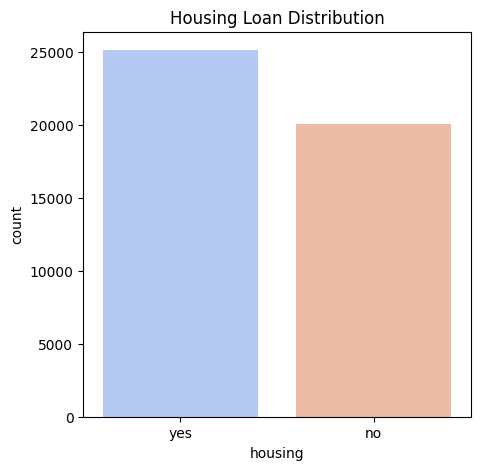

In [18]:
# Housing Loan Distribution
plt.figure(figsize=(5,5))

sns.countplot(x='housing', data=df, palette='coolwarm')

plt.title("Housing Loan Distribution")

plt.show()

### Observation

A larger proportion of customers have housing loans compared to those who do not.
Housing loan status may influence customers' purchasing decisions and could be an important predictive feature.


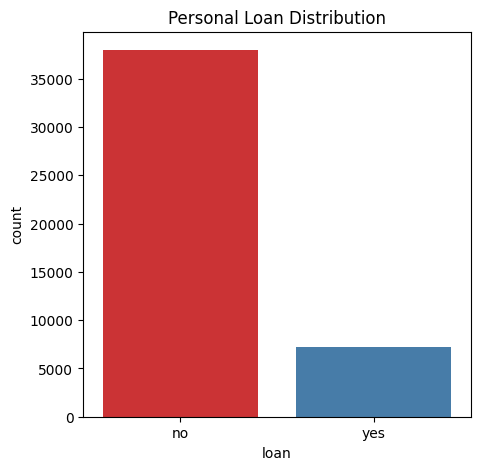

In [19]:
# Personal Loan Distribution
plt.figure(figsize=(5,5))

sns.countplot(x='loan', data=df, palette='Set1')

plt.title("Personal Loan Distribution")

plt.show()

### Observation:

Most customers do not have personal loans, while only a smaller percentage have personal loans.
This indicates that personal loan ownership is less common among the customers.

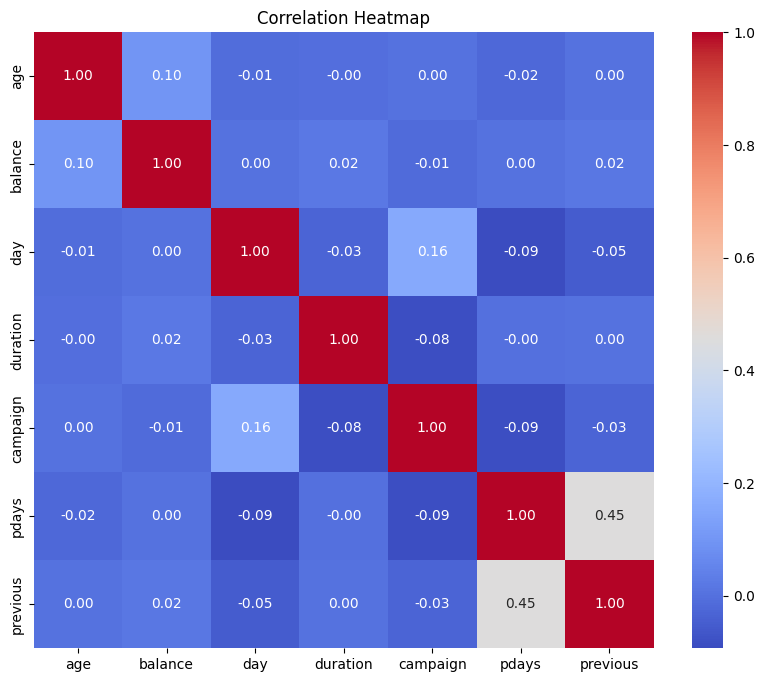

In [20]:
# Correlation Heatmap
plt.figure(figsize=(10,8))

numeric_df = df.select_dtypes(include=['int64','float64'])

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Correlation Heatmap")

plt.show()

### Observation:

Most numerical features exhibit weak correlations with one another, indicating low multicollinearity.
Each feature contributes different information, which is beneficial for building a Decision Tree model.


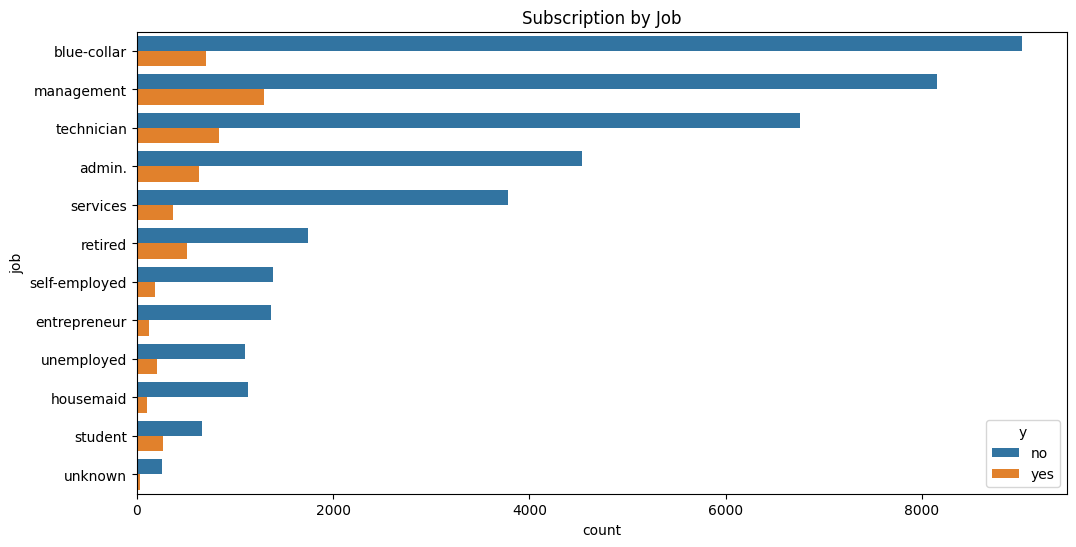

In [21]:
# Subscription by Job
plt.figure(figsize=(12,6))

sns.countplot(
    y='job',
    hue='y',
    data=df,
    order=df['job'].value_counts().index
)

plt.title("Subscription by Job")

plt.show()

### Observation:

Subscription rates vary across different job categories.
Certain occupations show a higher number of successful subscriptions than others,
suggesting that occupation may influence a customer's likelihood of subscribing.


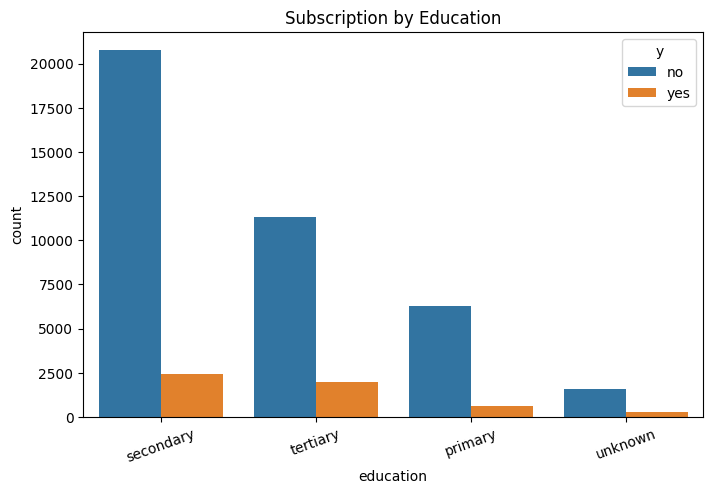

In [22]:
# Subscription by Education
plt.figure(figsize=(8,5))

sns.countplot(
    x='education',
    hue='y',
    data=df,
    order=df['education'].value_counts().index
)

plt.title("Subscription by Education")

plt.xticks(rotation=20)

plt.show()

### Observation:

Customers with secondary education form the largest group of both subscribers and non-subscribers.
However, the overall number of non-subscribers remains higher across all education levels due to class imbalance.


## Data Preprocessing

In [23]:
# Check for 'unknown' values in categorical columns

categorical_cols = df.select_dtypes(include='object').columns

for col in categorical_cols:
    unknown_count = (df[col] == 'unknown').sum()
    print(f"{col}: {unknown_count}")

job: 288
marital: 0
education: 1857
default: 0
housing: 0
loan: 0
contact: 13020
month: 0
poutcome: 36959
y: 0


### Observation:

The dataset contains 'unknown' values in a few categorical features such as job,
education, contact, and poutcome. These are treated as valid categories rather than
missing values, so no additional handling is required for a Decision Tree model.


In [24]:
# Encode categorical variables

label_encoder = LabelEncoder()

for col in categorical_cols:
    df[col] = label_encoder.fit_transform(df[col])

print("Categorical features encoded successfully.")

Categorical features encoded successfully.


In [27]:
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,4,1,2,0,2143,1,0,2,5,8,261,1,-1,0,3,0
1,44,9,2,1,0,29,1,0,2,5,8,151,1,-1,0,3,0
2,33,2,1,1,0,2,1,1,2,5,8,76,1,-1,0,3,0
3,47,1,1,3,0,1506,1,0,2,5,8,92,1,-1,0,3,0
4,33,11,2,3,0,1,0,0,2,5,8,198,1,-1,0,3,0


In [28]:
# checking Data Types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   age        45211 non-null  int64
 1   job        45211 non-null  int64
 2   marital    45211 non-null  int64
 3   education  45211 non-null  int64
 4   default    45211 non-null  int64
 5   balance    45211 non-null  int64
 6   housing    45211 non-null  int64
 7   loan       45211 non-null  int64
 8   contact    45211 non-null  int64
 9   day        45211 non-null  int64
 10  month      45211 non-null  int64
 11  duration   45211 non-null  int64
 12  campaign   45211 non-null  int64
 13  pdays      45211 non-null  int64
 14  previous   45211 non-null  int64
 15  poutcome   45211 non-null  int64
 16  y          45211 non-null  int64
dtypes: int64(17)
memory usage: 5.9 MB


### Observation:

All categorical variables have been successfully converted into numerical format.
The dataset is now ready for machine learning model training.


In [29]:
# Features and Target Variable

X = df.drop('y', axis=1)
y = df['y']

In [30]:
# Verifying shapes
print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (45211, 16)
Target Shape: (45211,)


In [31]:
# Split the dataset into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [32]:
# Verify the split
print("Training Features :", X_train.shape)
print("Testing Features  :", X_test.shape)

print("Training Labels   :", y_train.shape)
print("Testing Labels    :", y_test.shape)

Training Features : (36168, 16)
Testing Features  : (9043, 16)
Training Labels   : (36168,)
Testing Labels    : (9043,)


### Observation:

The dataset has been successfully divided into training and testing sets using an
80:20 ratio. The training data will be used to build the Decision Tree model,
while the testing data will be used to evaluate its performance on unseen data.


## Build the Decision Tree Classifier

In [39]:
# Train the model
# Create the Decision Tree model

dt_model = DecisionTreeClassifier(
    criterion='gini',
    max_depth=5,
    random_state=42
)

# Train the model
dt_model.fit(X_train, y_train)

print("Decision Tree Classifier trained successfully.")

Decision Tree Classifier trained successfully.


In [40]:
# Predict on the test set

y_pred = dt_model.predict(X_test)

In [41]:
# Calculate accuracy

accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.2%}")

Accuracy: 89.35%


### Observation:

The Decision Tree model achieved a high accuracy on the test dataset,
indicating that it performs well in classifying customer subscription outcomes.


<Figure size 600x500 with 0 Axes>

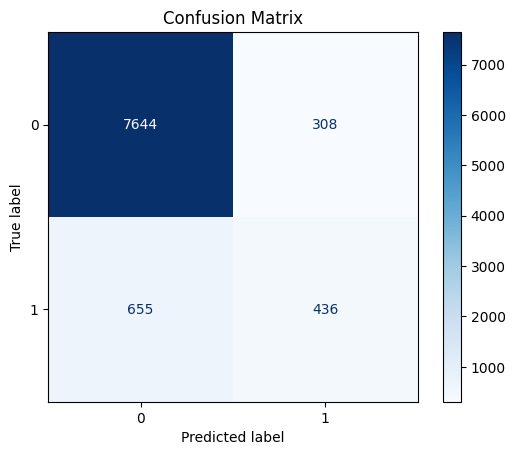

In [42]:
# Plot Confusion Matrix

plt.figure(figsize=(6,5))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    cmap='Blues'
)

plt.title("Confusion Matrix")

plt.show()

### Observation:

The confusion matrix indicates that the model correctly classified most of the
customers. However, some customers who actually subscribed were misclassified as
non-subscribers, reflecting the impact of class imbalance on model performance.


In [43]:
# Classification Report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.92      0.96      0.94      7952
           1       0.59      0.40      0.48      1091

    accuracy                           0.89      9043
   macro avg       0.75      0.68      0.71      9043
weighted avg       0.88      0.89      0.88      9043



# Observation:

The classification report provides precision, recall, and F1-score for both classes.
The model performs better on the majority class ("no") than on the minority class ("yes"),
which is expected because the dataset is imbalanced.


## Visualize the Decision Tree

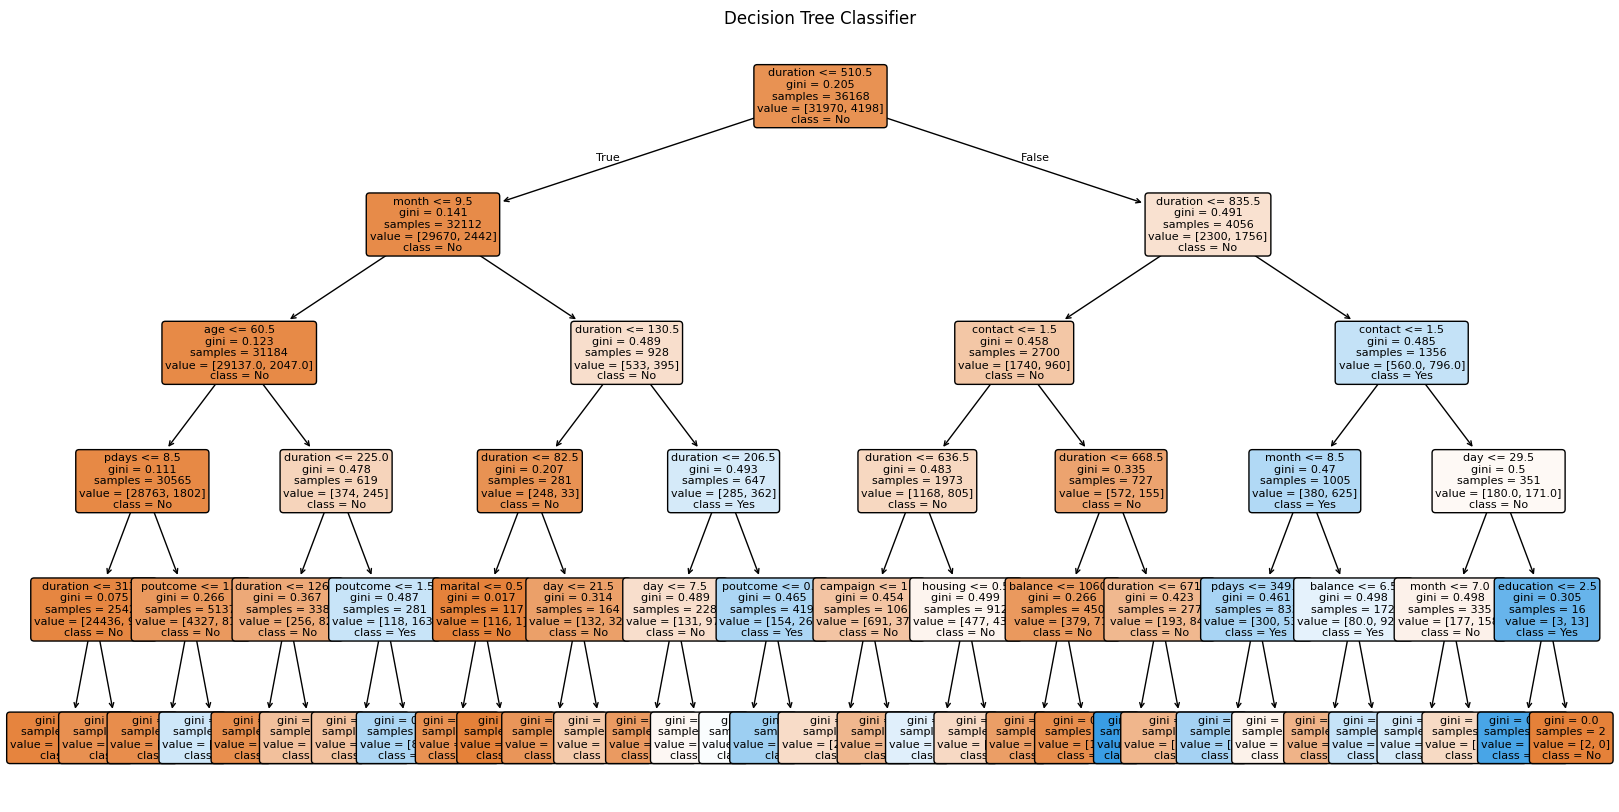

In [44]:
# Plot the Decision Tree

plt.figure(figsize=(20,10))

plot_tree(
    dt_model,
    feature_names=X.columns,
    class_names=['No', 'Yes'],
    filled=True,
    rounded=True,
    fontsize=8
)

plt.title("Decision Tree Classifier")

plt.show()

### Observation:

The Decision Tree visualization illustrates the sequence of decision rules used by
the model to classify customers. Each split is based on the feature that best
separates the data at that stage.


## Feature Importance

In [45]:
# Feature Importance

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': dt_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

feature_importance

,Feature,Importance
11,duration,0.578134
15,poutcome,0.144215
10,month,0.113463
0,age,0.065036
13,pdays,0.057855
8,contact,0.023506
9,day,0.006439
6,housing,0.003712
12,campaign,0.003335
5,balance,0.002783


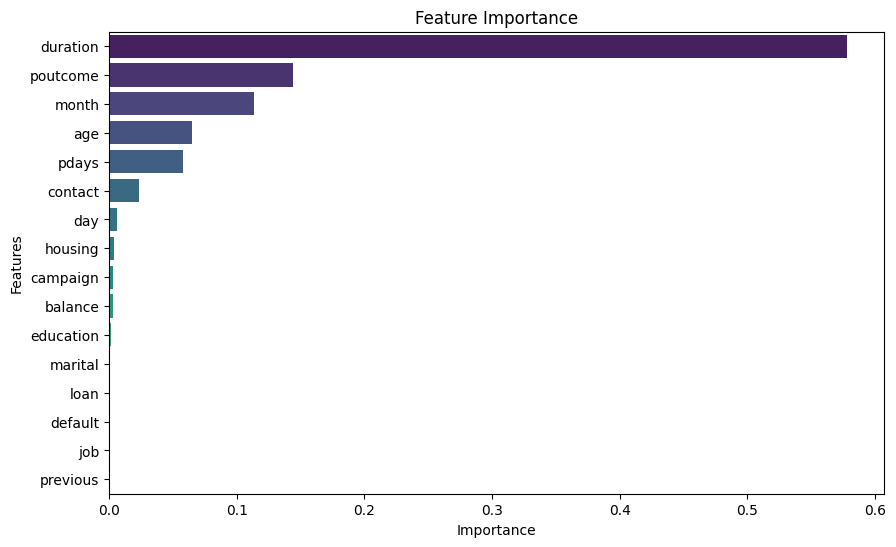

In [46]:
# Plot Feature Importance

plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance,
    x='Importance',
    y='Feature',
    palette='viridis'
)

plt.title("Feature Importance")

plt.xlabel("Importance")
plt.ylabel("Features")

plt.show()

### Observation:

The feature importance analysis reveals that 'duration' is the most influential
feature in predicting customer subscription, followed by 'poutcome', 'month',
'age', and 'pdays'. Features such as 'job', 'default', 'loan', and 'previous'
have little to no impact on the model's predictions.


## Final Insights:

1. The Decision Tree Classifier achieved an overall accuracy of 89.35% on the test dataset.

2. The dataset is imbalanced, with significantly more "No" than "Yes" responses,
which affected the model's ability to accurately predict the minority class.

3. The model performed exceptionally well in identifying customers who did not
subscribe but showed lower recall for customers who subscribed.

4. Feature importance analysis identified 'duration', 'poutcome', 'month', 'age',
and 'pdays' as the most influential predictors of customer subscription.

5. Decision Trees provide interpretable decision rules, making them useful for
understanding customer behavior and identifying factors that influence marketing
campaign outcomes.
